# Lab 1

## Estimating worst-case/average-case complexity of algorithms via linear and binary search.

### 1. Linear Search

In [1]:
import math
import random

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd
import csv
csv.field_size_limit(10**10)  # Increase CSV field size limit to handle large data

131072

In [2]:
n = 0 # no. of iterations

In [3]:
def linearSearch(arr, q):
    global n
    for i in range(1, len(arr)):
        n = n + 1
        if (arr[i] == q):
            return i

In [4]:
def testLinearSearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    # Run the algorithm
    linearSearch(arr,q)
    return n, (arr, q)                                      # Modifications as mentioned by Faculty

def data_builder(n):
    arr = []
    for i in range(1, n):
        # print(10**i)
        for j in range(1, 10):
            arr.append((10**i)*j)
    return arr

def run_n_times(iterations, sample_size):
    # initialise datastores
    test_sizes = data_builder(sample_size)
    results = [0 for i in range(len(test_sizes))]
    arr_queries_datastore = []                              # Modifications as mentioned by Faculty
    # run the tests for iterations
    for i in range(iterations):
        for j in range(len(test_sizes)):
            n, (arr, queries) = testLinearSearch(test_sizes[j], test_sizes[j])
            results[j] += n
            arr_queries_datastore.append((arr, queries, n)) # Modifications as mentioned by Faculty
    # calculate avg comparisons
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return (test_sizes, results, arr_queries_datastore)     # Modifications as mentioned by Faculty

In [5]:
ITER_RUNS = 25
RUN_SIZE = 4
test_sizes, results, arr_queries_datastore = run_n_times(ITER_RUNS, RUN_SIZE)

In [6]:
for i in range(len(arr_queries_datastore)):
    row = arr_queries_datastore[i]
    row_modifiable = list(row)
    row_modifiable.append(len(row_modifiable[0]))
    row_modifiable[0] = str(row_modifiable[0]).replace(',', ' ') # Enhance CSV Compatibility  
    row = tuple(row_modifiable)
    arr_queries_datastore[i] = row

In [7]:
results_dataset = pd.DataFrame(arr_queries_datastore, columns=['Array', 'Query', 'Iterations (Linear Search)', 'Data Size']) # Modifications as mentioned by Faculty

In [8]:
results_dataset

,Array,Query,Iterations (Linear Search),Data Size
0,[2 9 9 7 0 10 2 10 6 4],0,4,10
1,[3 0 12 7 5 12 11 0 20 7 8 4 6 1 ...,12,2,20
2,[18 9 27 19 11 26 26 8 5 21 20 18 ...,20,10,30
3,[3 23 7 3 24 6 20 39 37 20 3 30 0 ...,27,39,40
4,[12 0 42 41 38 45 5 49 12 34 37 33 ...,44,29,50
...,...,...,...,...
670,[69 3980 481 3788 566 1843 4632 167 19...,2009,375,5000
671,[4359 4803 5673 4400 1381 1233 4698 578...,2874,1481,6000
672,[6806 758 3210 4253 805 6116 292 2958 ...,6571,5727,7000
673,[4825 4806 6491 2291 3025 2718 5073 912...,6586,7999,8000


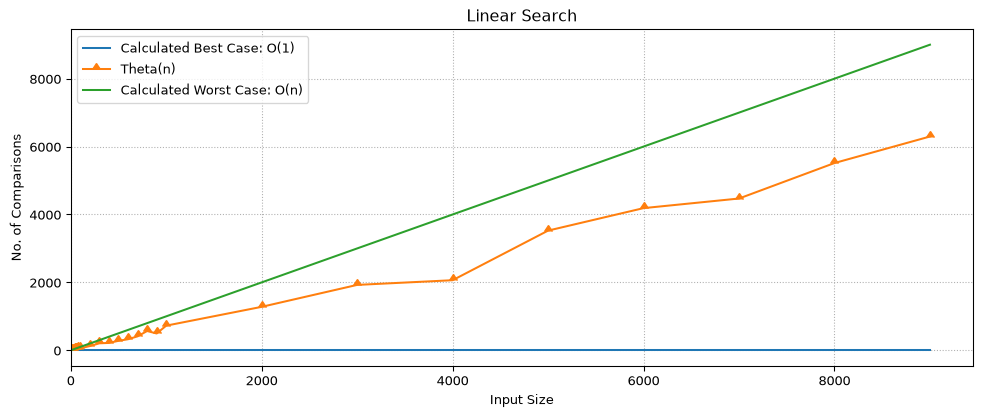

In [9]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # best case
y2 = results[:] # avg case
y3 = [i for i in test_sizes[:]] # worst case

plt.plot(x, y1, label="Calculated Best Case: O(1)")
plt.plot(x, y2, label="Theta(n)", marker=10)
plt.plot(x, y3, label="Calculated Worst Case: O(n)")

plt.xlim(left=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 2. Binary Search

In [10]:
n=0
def binarySearch(arr, q, low, high):
    global n
    if (low > high) or ((low == high) and (q != low)) or (high >= len(arr)):
        return None
    mid = int((high - low)//2) + low
    if arr[mid] == q:
        n += 1
        return mid
    if q < arr[mid]:
        n += 1
        return binarySearch(arr, q, low, mid-1)
    if q > arr[mid]:
        n += 1
        return binarySearch(arr, q, mid+1, high)
    return None

In [11]:
def testBinarySearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    arr.sort()
    # Run the algorithm
    binarySearch(arr,q,0,num-1)
    return n, (arr, q)                                # Modifications as mentioned by Faculty

def run_n_times_binary(iterations, sample_size):
    # initialise datastores
    test_sizes = data_builder(sample_size)
    results = [0 for i in range(len(test_sizes))]
    arr_queries_datastore_b = []                              # Modifications as mentioned by Faculty
    # run the tests for iterations
    for i in range(iterations):
        for j in range(len(test_sizes)):
            n, (arr, queries) = testBinarySearch(test_sizes[j], test_sizes[j])
            results[j] += n
            arr_queries_datastore_b.append((arr, queries, n)) # Modifications as mentioned by Faculty
    # calculate avg comparisons
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return (test_sizes, results, arr_queries_datastore_b)     # Modifications as mentioned by Faculty

In [12]:
ITER_RUNS_B = 25
RUN_SIZE_B = 4
test_sizes, results_b, arr_queries_datastore_b = run_n_times_binary(ITER_RUNS_B, RUN_SIZE_B)

In [13]:
for i in range(len(arr_queries_datastore_b)):
    row = arr_queries_datastore_b[i]
    row_modifiable = list(row)
    row_modifiable.append(len(row_modifiable[0]))
    row_modifiable[0] = str(row_modifiable[0]).replace(',', ' ') # Enhance CSV Compatibility
    row = tuple(row_modifiable)
    arr_queries_datastore_b[i] = row

In [14]:
results_dataset_b = pd.DataFrame(arr_queries_datastore_b, columns=['Array', 'Query', 'Iterations (Binary Search)', 'Data Size']) # Modifications as mentioned by Faculty

In [15]:
results_dataset_b

,Array,Query,Iterations (Binary Search),Data Size
0,[2 3 3 4 5 5 8 9 9 9],7,3,10
1,[0 1 1 2 5 6 9 11 12 13 13 15 15 ...,8,3,20
2,[0 0 2 3 5 7 9 10 12 12 13 14 15 ...,4,4,30
3,[1 1 2 3 3 4 4 4 5 6 6 7 7 7 9 ...,26,5,40
4,[2 3 4 4 4 6 6 7 7 7 7 10 10 12 ...,43,5,50
...,...,...,...,...
670,[0 0 1 1 2 3 4 4 5 6 9 10 13 14 ...,780,11,5000
671,[0 0 0 1 3 3 4 5 6 6 6 7 7 8 8 ...,2572,11,6000
672,[0 0 1 1 1 3 6 8 9 12 13 13 14 15...,458,11,7000
673,[0 0 0 0 1 1 2 2 2 3 3 5 6 6 6 ...,3278,10,8000


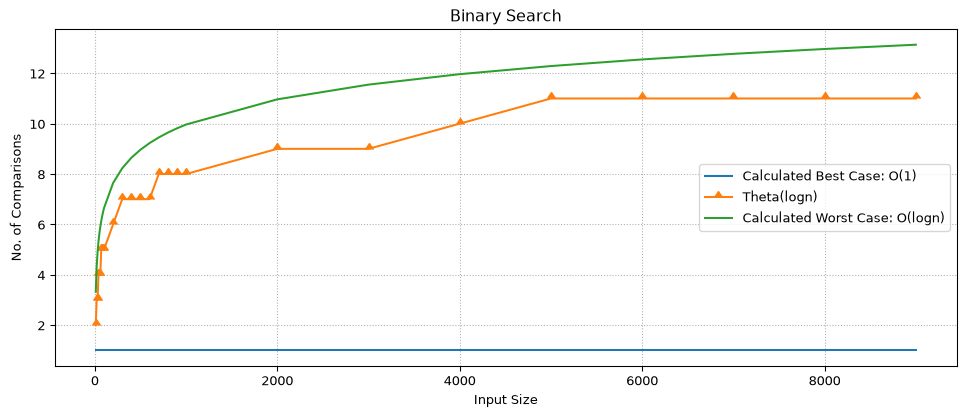

In [16]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # best case
y2 = results_b[:] # avg case
y3 = [math.log2(i) for i in test_sizes[:]] # worst case

plt.plot(x, y1, label="Calculated Best Case: O(1)")
plt.plot(x, y2, label="Theta(logn)", marker=10)
plt.plot(x, y3, label="Calculated Worst Case: O(logn)")

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 3. Comparison b/w Linear and Binary Search Algorithms

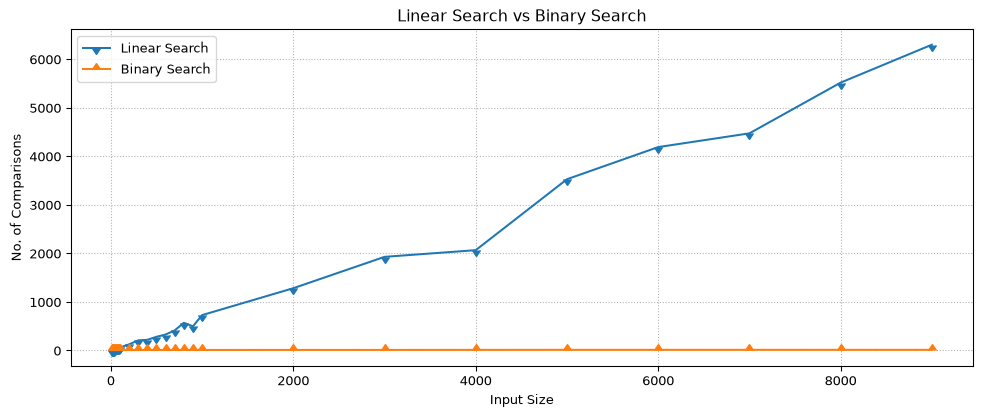

In [17]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = results[:] # Linear Search
y2 = results_b[:] # Binary Search

plt.plot(x, y1, label="Linear Search", marker=11)
plt.plot(x, y2, label="Binary Search", marker=10)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search vs Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

# Save the Datasets and Search Results

In [18]:
results_dataset.to_csv('2650026_lab1_data0.csv', index=False, lineterminator='\n')
results_dataset_b.to_csv('2650026_lab1_data1.csv', index=False, lineterminator='\n')

In [19]:
summarised_results_df = pd.DataFrame([test_sizes, results, results_b], index=['Input Size', 'Iterations (Linear Search, '+str(ITER_RUNS)+' runs)', 'Iterations (Binary Search, '+str(ITER_RUNS_B)+' runs)']).transpose()
summarised_results_df.to_csv('2650026_lab1_summary.csv', index=False, lineterminator='\n')